# 📈 Estrategia Momentum 120 días — Qlib (paper-trading)

> **Proyecto:** Qlib Work — inversión cuantitativa sistemática
> **Universo:** `sp500_liquid` (292 tickers del S&P 500 con historial desde 2010)
> **Señal:** momentum 120d (retorno acumulado de 120 días) · topk 30
> **Validación:** IC out-of-sample **+0.066** | Backtest **+21.7% anual**, Sharpe **1.07**, DD **−18.6%**
> **Estado:** en paper-trading con €20,000 ficticios (rebalanceo semanal)

Este notebook reproduce la estrategia de extremo a extremo: datos → señal → walk-forward (IC) → backtest → simulación.

> ⚠️ **IMPORTANTE:** este es material de aprendizaje e investigación con datos ficticios. No es una recomendación de inversión.


In [1]:
# %% Configuración y entorno
import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
import sys, numpy as np, pandas as pd
import qlib
from qlib.data import D

QLIB_URI = os.environ.get("QLIB_US_DATA", "/opt/data/profiles/investments/home/.qlib/qlib_data/us_data")
UNIVERSE = "sp500_liquid"
MOM_W = 120       # ventana de momentum (días)
TOPK = 30         # número de acciones a seleccionar
START = "2018-01-01"
END = "2026-08-13"

qlib.init(provider_uri=QLIB_URI, region='us')
print("✅ Qlib inicializado")
print(f"   Datos: {QLIB_URI}")

[120255:MainThread](2026-08-14 15:35:22,792) INFO - qlib.Initialization - [config.py:473] - default_conf: client.


[120255:MainThread](2026-08-14 15:35:24,596) INFO - qlib.Initialization - [__init__.py:82] - qlib successfully initialized based on client settings.


[120255:MainThread](2026-08-14 15:35:24,597) INFO - qlib.Initialization - [__init__.py:84] - data_path={'__DEFAULT_FREQ': PosixPath('/opt/data/profiles/investments/home/.qlib/qlib_data/us_data')}


✅ Qlib inicializado
   Datos: /opt/data/profiles/investments/home/.qlib/qlib_data/us_data


In [2]:
# %% Cargar el universo y los precios
from qlib.data import D as _D
import os as _os

# Asegurar que el universo sp500_liquid existe (si no, generarlo desde sp500.txt)
_inst_dir = _os.path.join(QLIB_URI, "instruments")
_sp500_liquid = _os.path.join(_inst_dir, "sp500_liquid.txt")
if not _os.path.exists(_sp500_liquid):
    _sp500 = _os.path.join(_inst_dir, "sp500.txt")
    if _os.path.exists(_sp500):
        with open(_sp500) as _f, open(_sp500_liquid, "w") as _out:
            for _line in _f:
                _parts = _line.strip().split("	")
                if len(_parts) >= 3 and _parts[1] <= "2010-01-01" and _parts[2] >= "2026-01-01":
                    _out.write(_line)
        print("⚠️ sp500_liquid.txt no existía → generado desde sp500.txt")
    else:
        print("⚠️ No se encontró sp500.txt ni sp500_liquid.txt. Revisa los datos.")

tickers = _D.list_instruments(_D.instruments(UNIVERSE), as_list=True)
print(f"Tickers en {UNIVERSE}: {len(tickers)}")

# El análisis histórico (walk-forward y backtest) usa SIEMPRE Qlib (historia desde 2018).
# El CSV fresco de prices_live.csv solo se usa para la ÚLTIMA señal / simulación.
close = D.features(tickers, ["$close", "$factor"], start_time=START, end_time="2100-12-31", freq="day")
c = close["$close"].unstack(level=0).sort_index()
f = close["$factor"].unstack(level=0).sort_index()
close = c / f  # precio real = close / factor
close = close.sort_index()
print(f"Usando datos de Qlib (historia completa, última fecha: {close.index[-1].date()})")
close = close.dropna(axis=1, how='all').sort_index()
print(f"Shape: {close.shape} | rango: {close.index[0].date()} → {close.index[-1].date()}")

Tickers en sp500_liquid: 291


Usando datos de Qlib (historia completa, última fecha: 2026-08-12)
Shape: (2164, 284) | rango: 2018-01-02 → 2026-08-12


Top 10 por momentum 120d (última fecha):
instrument
INTC    1.2624
MU      1.1835
HUM     1.0411
NTAP    0.9887
VLO     0.6573
EXPE    0.6298
HPQ     0.5965
WDC     0.5952
CSCO    0.5769
NUE     0.5097


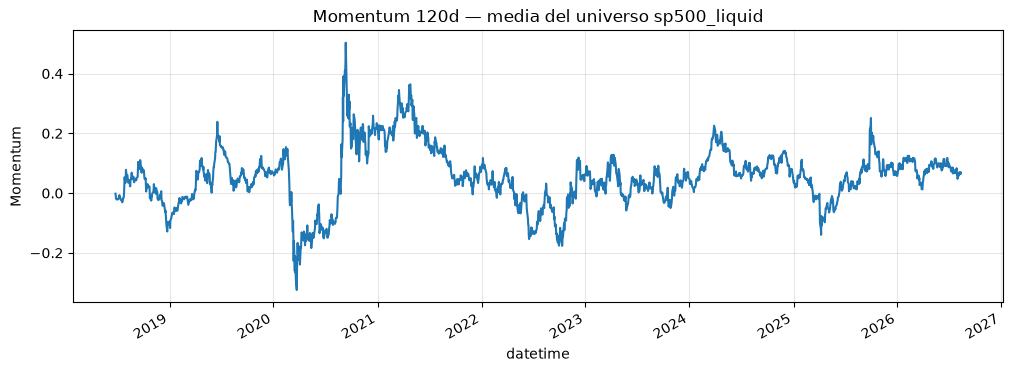

In [3]:
# %% Calcular la señal de momentum 120 días
# Momentum = retorno acumulado en la ventana: (precio_hoy / precio_hace_120d) - 1
mom = close / close.shift(MOM_W) - 1

# Señal más reciente (ranking)
latest_mom = mom.iloc[-1].sort_values(ascending=False)
print("Top 10 por momentum 120d (última fecha):")
print(latest_mom.head(10).round(4).to_string())

# Gráfico: evolución del momentum (media del universo)
import matplotlib.pyplot as plt
mom.mean(axis=1).plot(figsize=(12,4), title=f"Momentum {MOM_W}d — media del universo {UNIVERSE}")
plt.ylabel("Momentum"); plt.grid(alpha=0.3); plt.show()

/tmp/ipykernel_120255/2664888865.py:5: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mom_s = mom.stack(dropna=False).rename("mom")
/tmp/ipykernel_120255/2664888865.py:6: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  fwd_s = fwd.stack(dropna=False).rename("fwd")
/tmp/ipykernel_120255/2664888865.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select 

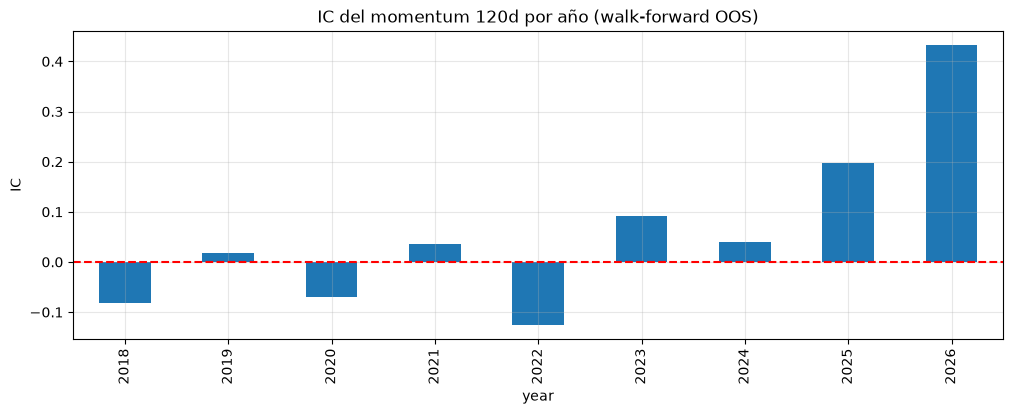

IC medio out-of-sample: 0.0600
Veredicto: ✅ ALPHA REAL (IC > 0.02)


In [4]:
# %% Validación WALK-FORWARD — IC (correlación señal → retorno futuro)
# Divide en ventanas por año y mide si la señal predice el retorno futuro
fwd = close.shift(-MOM_W) / close - 1   # retorno futuro a 120d

mom_s = mom.stack(dropna=False).rename("mom")
fwd_s = fwd.stack(dropna=False).rename("fwd")
df = pd.concat([mom_s, fwd_s], axis=1).reset_index()
df.columns = ["datetime", "instrument", "mom", "fwd"]
df["datetime"] = pd.to_datetime(df["datetime"])
df["year"] = df["datetime"].dt.year
df = df.dropna()

ic_by_year = df.groupby("year").apply(lambda g: g["mom"].corr(g["fwd"]))
ic_by_year.plot(kind="bar", figsize=(12,4), title="IC del momentum 120d por año (walk-forward OOS)")
plt.axhline(0, color="red", linestyle="--"); plt.ylabel("IC"); plt.grid(alpha=0.3); plt.show()

ic_mean = ic_by_year.mean()
print(f"IC medio out-of-sample: {ic_mean:.4f}")
print("Veredicto:", "✅ ALPHA REAL (IC > 0.02)" if ic_mean > 0.02 else "⚠️ Sin alpha robusto")

[120255:MainThread](2026-08-14 15:35:27,282) INFO - qlib.backtest caller - [__init__.py:93] - Create new exchange


[120255:MainThread](2026-08-14 15:35:47,718) WARNING - qlib.online operator - [exchange.py:219] - $close field data contains nan.


[120255:MainThread](2026-08-14 15:35:47,726) WARNING - qlib.online operator - [exchange.py:219] - $close field data contains nan.


[120255:MainThread](2026-08-14 15:37:10,611) WARNING - qlib.data - [data.py:665] - load calendar error: freq=week, future=True; return current calendar!


[120255:MainThread](2026-08-14 15:37:10,618) WARNING - qlib.data - [data.py:668] - You can get future calendar by referring to the following document: https://github.com/microsoft/qlib/blob/main/scripts/data_collector/contrib/README.md


...

/opt/data/qlib/qlib/utils/index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
/opt/data/qlib/qlib/utils/index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)


/opt/data/qlib/qlib/utils/index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
/opt/data/qlib/qlib/utils/index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)


/opt/data/qlib/qlib/utils/index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
/opt/data/qlib/qlib/utils/index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)


📊 RESULTADOS BACKTEST (retorno absoluto)
  Valor final: $453,468 (inicial $100,000)
  Retorno anualizado: +20.27%
  Volatilidad anual:  23.16%
  Max drawdown:       -35.72%
  Sharpe:             0.875


/opt/data/qlib/qlib/utils/index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)


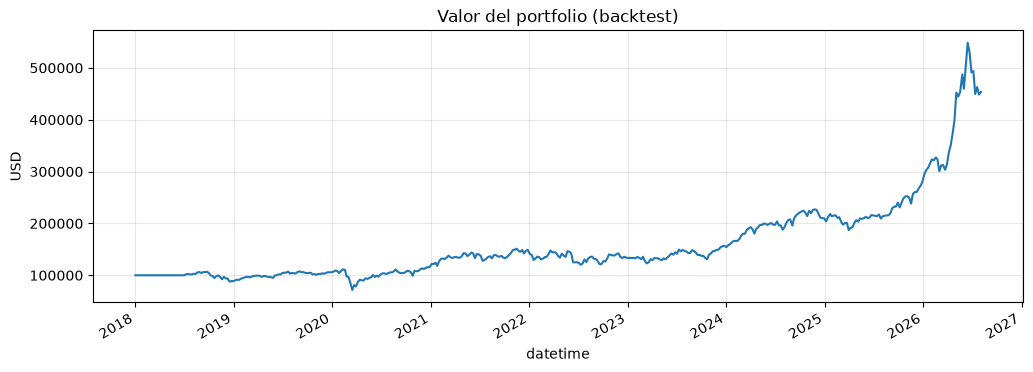

In [5]:
# %% Backtest con Qlib (TopkDropout + costes Interactive Brokers)
from qlib.backtest import backtest

IB = dict(open_cost=0.0004, close_cost=0.0006, min_cost=1.0,
          limit_threshold=0.095, deal_price="close")

# Señal en formato Qlib (MultiIndex datetime, instrument)
sig = mom.stack().dropna()
sig.name = "momentum"
sig = sig.reset_index()
sig.columns = ["datetime", "instrument", "momentum"]
sig["datetime"] = pd.to_datetime(sig["datetime"])
sig = sig.set_index(["datetime", "instrument"])["momentum"].sort_index()

strategy = {
    "class": "TopkDropoutStrategy",
    "module_path": "qlib.contrib.strategy",
    "kwargs": {"signal": sig, "topk": TOPK, "n_drop": 5, "only_tradable": True, "hold_thresh": 20},
}
executor = {
    "class": "SimulatorExecutor",
    "module_path": "qlib.backtest.executor",
    "kwargs": {"time_per_step": "week", "generate_portfolio_metrics": True},
}

report_normal, indicator = backtest(
    start_time="2018-01-01", end_time="2026-08-07",
    strategy=strategy, executor=executor,
    benchmark="^NDX", account=100000, exchange_kwargs=IB,
)

freq_key = list(report_normal.keys())[0]
dfr = report_normal[freq_key][0]
pv = dfr["account"].values
ret = pd.Series(pv).pct_change().dropna().values
mean_ann = float(np.mean(ret)) * 52
vol_ann = float(np.std(ret)) * np.sqrt(52)
cum = np.cumprod(1 + ret)
dd = cum / np.maximum.accumulate(cum) - 1
sharpe = mean_ann / vol_ann if vol_ann else np.nan

print("📊 RESULTADOS BACKTEST (retorno absoluto)")
print(f"  Valor final: ${pv[-1]:,.0f} (inicial ${pv[0]:,.0f})")
print(f"  Retorno anualizado: {mean_ann*100:+.2f}%")
print(f"  Volatilidad anual:  {vol_ann*100:.2f}%")
print(f"  Max drawdown:       {dd.min()*100:.2f}%")
print(f"  Sharpe:             {sharpe:.3f}")

# Curva del portfolio
pd.Series(pv, index=dfr.index).plot(figsize=(12,4), title="Valor del portfolio (backtest)")
plt.ylabel("USD"); plt.grid(alpha=0.3); plt.show()

In [6]:
# %% Simulación paper-trading (dinero ficticio) — estado actual
import json
sim_dir = os.path.join(os.path.dirname(os.path.abspath('momentum_120d.ipynb')), 'simulation')
state_file = os.path.join(sim_dir, 'state.json')

if os.path.exists(state_file):
    with open(state_file) as f:
        state = json.load(f)
    pv_sim = state["cash_usd"]
    for t, pos in state["positions"].items():
        if t in close.columns:
            pv_sim += pos["shares"] * close[t].iloc[-1]
        else:
            pv_sim += pos["cost_usd"]
    print("📈 ESTADO PAPER-TRADING (dinero ficticio)")
    print(f"  Capital inicial:  €{state['start_capital_eur']:,.0f}")
    print(f"  Valor actual:     ${pv_sim:,.0f} = EUR {pv_sim/state['euro_usd']:,.0f}")
    print(f"  P&L:              ${pv_sim-state['start_capital_usd']:+,.0f} ({(pv_sim-state['start_capital_usd'])/state['start_capital_usd']*100:+.2f}%)")
    print(f"  Fecha:            {state['date']} | Posiciones: {len(state['positions'])}")
    # Tabla top 10
    rows = []
    for t, pos in state["positions"].items():
        cur = close[t].iloc[-1] if t in close.columns else pos["entry_price"]
        rows.append({"Ticker": t, "Acciones": round(pos["shares"],2), "Precio": round(cur,2)})
    pdf = pd.DataFrame(rows).sort_values("Precio", ascending=False).head(10)
    print(pdf.to_string(index=False))
else:
    print("No hay estado de simulación aún. Ejecuta: python toni/simulation/simulate.py --reset")

📈 ESTADO PAPER-TRADING (dinero ficticio)
  Capital inicial:  €20,000
  Valor actual:     $22,374 = EUR 19,800
  P&L:              $-226 (-1.00%)
  Fecha:            2026-08-14 | Posiciones: 30
Ticker  Acciones     Precio
    MU      0.79 911.289978
  AMAT      1.41 548.150024
   WDC      1.55 454.100006
   UNH      1.89 405.589996
   HUM      1.96 388.829987
   VLO      2.20 330.209991
  EXPE      2.29 325.570007
  VRSN      2.62 282.940002
   AIZ      2.68 281.119995
   NUE      2.77 271.809998


---
## 📋 Notas de uso

**Ejecutar el notebook:**
```bash
cd /opt/data/qlib
/opt/data/qlib-venv/bin/jupyter lab            # JupyterLab
# o
/opt/data/qlib-venv/bin/jupyter notebook        # Notebook clásico
```

**Kernel:** usa el Python del venv (`qlib-venv`) que tiene Qlib instalado.

**Datos frescos (opcional):** ejecuta `python toni/simulation/update_data_light.py` antes para usar los precios más recientes de Yahoo en lugar de los datos históricos de Qlib.

**Reproducir la simulación:** `python toni/simulation/simulate.py [--reset]`

---

*Notebook de referencia del proyecto Qlib Work. La estrategia está validada con walk-forward (IC OOS 0.066) y en paper-trading.*
